In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score

from datasets import Dataset, load_dataset

BASE_DIR_DATA = "/kaggle/input/datasets/fasihhk/securiti-internship-data"
BASE_DIR_OUTPUT = "/kaggle/working"

In [2]:
df_intern = pd.read_json(f"{BASE_DIR_DATA}/data/data.json")

df_intern.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28516 entries, 0 to 28515
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   lang      28516 non-null  object
 1   ner_tags  28516 non-null  object
 2   sequence  28516 non-null  object
 3   tokens    28516 non-null  object
dtypes: object(4)
memory usage: 891.3+ KB


In [3]:
df_intern.head()

,lang,ner_tags,sequence,tokens
0,en,"[O, O, O, O, B-PER, I-PER, O, O, O, O, B-PER, ...","Since then , only Terry Bradshaw in 147 games ...","[Since, then, ,, only, Terry, Bradshaw, in, 14..."
1,en,"[O, O, O, O, B-PER, I-PER, O, O, O, O, O, O, O...",He was portrayed by Anthony Perkins in the 196...,"[He, was, portrayed, by, Anthony, Perkins, in,..."
2,en,"[O, O, O, O, O, O, O, O, B-PER, O]","The egg eventually hatches , revealing a baby ...","[The, egg, eventually, hatches, ,, revealing, ..."
3,en,"[O, O, O, B-PER, O, O, O, O, O, O, O, O, O, O,...",In the video Kelis is walking down a street in...,"[In, the, video, Kelis, is, walking, down, a, ..."
4,en,"[O, O, O, O, B-PER, I-PER, I-PER, O, O, O, O, ...","According to food writer Sharon Tyler Herbst ,...","[According, to, food, writer, Sharon, Tyler, H..."


In [4]:
print(*zip(df_intern.iloc[0, 1], df_intern.iloc[0, 3]), sep="\n")

('O', 'Since')
('O', 'then')
('O', ',')
('O', 'only')
('B-PER', 'Terry')
('I-PER', 'Bradshaw')
('O', 'in')
('O', '147')
('O', 'games')
('O', ',')
('B-PER', 'Joe')
('I-PER', 'Montana')
('O', 'in')
('O', '139')
('O', 'games')
('O', ',')
('O', 'and')
('B-PER', 'Tom')
('I-PER', 'Brady')
('O', 'in')
('O', '131')
('O', 'games')
('O', 'have')
('O', 'reached')
('O', '100')
('O', 'wins')
('O', 'more')
('O', 'quickly')
('O', '.')


In [5]:
from collections import Counter
from functools import reduce

def count_email_rows(df: pd.DataFrame) -> int:
    email_rows = df['sequence'].str.contains(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}', regex=True)
    return email_rows.sum()

print("Email containing rows:", count_email_rows(df_intern))
print("# of languages:", df_intern['lang'].nunique())
print("Frequency of all token types", reduce(lambda frq, x: frq + Counter(x), df_intern['ner_tags'], Counter()))

Email containing rows: 0
# of languages: 1
Frequency of all token types Counter({'O': 639055, 'B-PER': 40264, 'I-PER': 29466})


In [6]:
df_edu = pd.read_json(f"{BASE_DIR_DATA}/data/edu-data/train.json")

df_edu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6807 entries, 0 to 6806
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   document             6807 non-null   int64 
 1   full_text            6807 non-null   object
 2   tokens               6807 non-null   object
 3   trailing_whitespace  6807 non-null   object
 4   labels               6807 non-null   object
dtypes: int64(1), object(4)
memory usage: 266.0+ KB


In [7]:
df_edu.columns = ["document", "sequence", "tokens", "trailing_whitespace", "ner_tags"]
df_edu = df_edu.drop(columns=["document", "trailing_whitespace"])
df_edu["lang"] = "en"

df_intern = df_intern.reindex(columns=sorted(df_intern.columns))
df_edu = df_edu.reindex(columns=sorted(df_edu.columns))

In [8]:
df_edu.head()

,lang,ner_tags,sequence,tokens
0,en,"[O, O, O, O, O, O, O, O, O, B-NAME_STUDENT, I-...",Design Thinking for innovation reflexion-Avril...,"[Design, Thinking, for, innovation, reflexion,..."
1,en,"[B-NAME_STUDENT, I-NAME_STUDENT, O, O, O, O, O...",Diego Estrada\n\nDesign Thinking Assignment\n\...,"[Diego, Estrada, \n\n, Design, Thinking, Assig..."
2,en,"[O, O, O, O, B-NAME_STUDENT, I-NAME_STUDENT, O...",Reporting process\n\nby Gilberto Gamboa\n\nCha...,"[Reporting, process, \n\n, by, Gilberto, Gambo..."
3,en,"[O, O, O, O, O, B-NAME_STUDENT, I-NAME_STUDENT...",Design Thinking for Innovation\n\nSindy Samaca...,"[Design, Thinking, for, Innovation, \n\n, Sind..."
4,en,"[O, O, O, O, O, O, O, O, O, O, O, O, B-NAME_ST...",Assignment: Visualization Reflection Submitt...,"[Assignment, :, , Visualization, , Reflecti..."


In [9]:
df = pd.concat((df_intern, df_edu), ignore_index=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35323 entries, 0 to 35322
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   lang      35323 non-null  object
 1   ner_tags  35323 non-null  object
 2   sequence  35323 non-null  object
 3   tokens    35323 non-null  object
dtypes: object(4)
memory usage: 1.1+ MB


In [10]:
print("Email containing rows:", count_email_rows(df))
print("# of languages:", df['lang'].nunique())
print()
print("Frequency of all token types:")
display(reduce(lambda frq, x: frq + Counter(x), df['ner_tags'], Counter()))
print()
print("Rows by source:")
print({
    "intern": len(df_intern),
    "edu": len(df_edu),
    "total": len(df),
})

Email containing rows: 25
# of languages: 1

Frequency of all token types:


Counter({'O': 5628849,
         'B-PER': 40264,
         'I-PER': 29466,
         'B-NAME_STUDENT': 1365,
         'I-NAME_STUDENT': 1096,
         'B-URL_PERSONAL': 110,
         'B-EMAIL': 39,
         'B-ID_NUM': 78,
         'I-URL_PERSONAL': 1,
         'B-USERNAME': 6,
         'B-PHONE_NUM': 6,
         'I-PHONE_NUM': 15,
         'B-STREET_ADDRESS': 2,
         'I-STREET_ADDRESS': 20,
         'I-ID_NUM': 1})


Rows by source:
{'intern': 28516, 'edu': 6807, 'total': 35323}


## Transformer NER Pipeline (Names + Emails)
This section fine-tunes an encoder model (`roberta-base`) for token-level PII tagging and evaluates masking quality for **name** and **email** entities with:
- Accuracy
- FPR
- FNR
- Precision
- Recall
- F1-score

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
)

MODEL_NAME = "roberta-base"
RANDOM_STATE = 42
MAX_LENGTH = 96

label_list = ["O", "B-PER", "I-PER", "B-EMAIL", "I-EMAIL"]
label2id = {label: idx for idx, label in enumerate(label_list)}
id2label = {idx: label for label, idx in label2id.items()}

In [ ]:
train_df = df.copy()

# Normalize expected schema.
required_cols = {"tokens", "ner_tags", "sequence", "lang"}
missing = required_cols - set(train_df.columns)
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

# Ensure tags are mapped into the final label space.
def normalize_tags(tags):
    normalized = []
    for t in tags:
        mapped = None

        if isinstance(t, (int, np.integer)):
            mapped = id2label.get(int(t))
        else:
            text = str(t).strip()
            if text in label2id:
                mapped = text
            elif text.isdigit():
                mapped = id2label.get(int(text))

        if mapped is None:
            mapped = "O"

        normalized.append(mapped)
    return normalized

train_df["ner_tags"] = train_df["ner_tags"].apply(normalize_tags)

train_idx, val_idx = train_test_split(
    np.arange(len(train_df)), test_size=0.1, random_state=RANDOM_STATE, shuffle=True
)
train_split = train_df.iloc[train_idx].reset_index(drop=True)
val_split = train_df.iloc[val_idx].reset_index(drop=True)

train_ds = Dataset.from_pandas(train_split[["tokens", "ner_tags"]], preserve_index=False)
val_ds = Dataset.from_pandas(val_split[["tokens", "ner_tags"]], preserve_index=False)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_and_align_labels(batch):
    tokenized = tokenizer(
        batch["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=MAX_LENGTH,
    )
    labels = []
    for i, word_labels in enumerate(batch["ner_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label2id[word_labels[word_idx]])
            else:
                current_label = word_labels[word_idx]
                if current_label.startswith("B-"):
                    current_label = "I-" + current_label[2:]
                label_ids.append(label2id.get(current_label, label2id["O"]))
            previous_word_idx = word_idx
        labels.append(label_ids)
    tokenized["labels"] = labels
    return tokenized

train_tok = train_ds.map(tokenize_and_align_labels, batched=True)
val_tok = val_ds.map(tokenize_and_align_labels, batched=True)

print(f"Train size: {len(train_tok)} | Val size: {len(val_tok)}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/31790 [00:00<?, ? examples/s]

Map:   0%|          | 0/3533 [00:00<?, ? examples/s]

Train size: 31790 | Val size: 3533


In [ ]:
import torch
import torch.nn as nn

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
)

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

class_weights = torch.tensor([
    1.0,  # O
    1.8,  # B-PER
    1.8,  # I-PER
    8.0,  # B-EMAIL
    8.0,  # I-EMAIL
], dtype=torch.float)


class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(
            input_ids=inputs.get("input_ids"),
            attention_mask=inputs.get("attention_mask"),
            labels=None,
        )
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device),
            ignore_index=-100,
        )
        loss = loss_fct(logits.view(-1, logits.size(-1)), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


use_cuda = torch.cuda.is_available()
print("CUDA available:", use_cuda)
if use_cuda:
    print("GPU:", torch.cuda.get_device_name(0))

training_args = TrainingArguments(
    output_dir=f"{BASE_DIR_OUTPUT}/roberta_pii",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_steps=100,
    report_to="none",
    fp16=use_cuda,
    dataloader_pin_memory=use_cuda,
    dataloader_num_workers=2,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=data_collator,
    processing_class=tokenizer,
)

trainer.train()

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForTokenClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.weight               | MISSING    | 
classifier.bias                 | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


CUDA available: True
GPU: Tesla T4


Epoch,Training Loss,Validation Loss
1,0.014351,0.012713
2,0.011325,0.010929
3,0.007067,0.011585


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2982, training_loss=0.01809101153507399, metrics={'train_runtime': 1179.0712, 'train_samples_per_second': 80.886, 'train_steps_per_second': 2.529, 'total_flos': 4671769766564160.0, 'train_loss': 0.01809101153507399, 'epoch': 3.0})

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


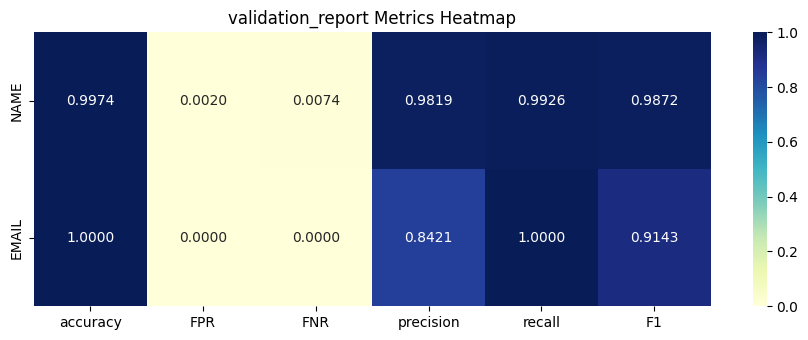

validation_report token accuracy: 0.9973
Saved report: /kaggle/working/reports/validation_report.csv
Saved heatmap: /kaggle/working/reports/validation_report_heatmap.png
Email recall bias enabled: True, threshold=0.2


,accuracy,FPR,FNR,precision,recall,F1,support_positive
NAME,0.997415,0.002043,0.00745,0.981883,0.99255,0.987188,16108
EMAIL,0.999981,0.000019,0.00000,0.842105,1.00000,0.914286,16


In [ ]:
from pathlib import Path

REPORT_DIR = Path(f"{BASE_DIR_OUTPUT}/reports")
REPORT_DIR.mkdir(parents=True, exist_ok=True)


def entity_binary_metrics(y_true_labels, y_pred_labels, positive_prefix):
    y_true_bin = [1 if label.endswith(positive_prefix) else 0 for label in y_true_labels]
    y_pred_bin = [1 if label.endswith(positive_prefix) else 0 for label in y_pred_labels]

    tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1]).ravel()
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_bin, y_pred_bin, average="binary", zero_division=0
    )
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    fnr = fn / (fn + tp) if (fn + tp) else 0.0

    return {
        "accuracy": accuracy,
        "FPR": fpr,
        "FNR": fnr,
        "precision": precision,
        "recall": recall,
        "F1": f1,
        "support_positive": int(sum(y_true_bin)),
    }


def evaluate_and_report(
    model_obj,
    dataset_tok,
    report_name,
    processing_tokenizer=None,
    prioritize_email_recall=True,
    email_threshold=0.20,
):
    allowed_cols = {"input_ids", "attention_mask", "token_type_ids", "labels"}
    drop_cols = [c for c in dataset_tok.column_names if c not in allowed_cols]
    dataset_for_pred = dataset_tok.remove_columns(drop_cols) if drop_cols else dataset_tok
    
    eval_args = TrainingArguments(
        output_dir=str(REPORT_DIR / "tmp_eval"),
        report_to="none",
        per_device_eval_batch_size=16,
        remove_unused_columns=False,
    )
    eval_trainer = Trainer(
        model=model_obj,
        args=eval_args,
        data_collator=DataCollatorForTokenClassification(tokenizer=processing_tokenizer or tokenizer),
        processing_class=processing_tokenizer or tokenizer,
    )

    pred_out = eval_trainer.predict(dataset_for_pred)
    logits = pred_out.predictions
    pred_ids = logits.argmax(axis=-1)
    true_ids = pred_out.label_ids

    if prioritize_email_recall:
        probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
        email_idxs = [label2id["B-EMAIL"], label2id["I-EMAIL"]]
        for i in range(pred_ids.shape[0]):
            for j in range(pred_ids.shape[1]):
                if true_ids[i, j] == -100:
                    continue
                email_prob = probs[i, j, email_idxs].max()
                if email_prob >= email_threshold:
                    pred_ids[i, j] = email_idxs[int(probs[i, j, email_idxs[1]] > probs[i, j, email_idxs[0]])]

    y_true, y_pred = [], []
    for pred_row, true_row in zip(pred_ids, true_ids):
        for p, t in zip(pred_row, true_row):
            if t == -100:
                continue
            y_true.append(id2label[int(t)])
            y_pred.append(id2label[int(p)])

    overall_acc = accuracy_score(y_true, y_pred)
    name_metrics = entity_binary_metrics(y_true, y_pred, "PER")
    email_metrics = entity_binary_metrics(y_true, y_pred, "EMAIL")

    report_df = pd.DataFrame([name_metrics, email_metrics], index=["NAME", "EMAIL"])
    csv_path = REPORT_DIR / f"{report_name}.csv"
    report_df.to_csv(csv_path)

    heatmap_values = report_df[["accuracy", "FPR", "FNR", "precision", "recall", "F1"]]
    plt.figure(figsize=(9, 3.5))
    sns.heatmap(heatmap_values, annot=True, fmt=".4f", cmap="YlGnBu", cbar=True)
    plt.title(f"{report_name} Metrics Heatmap")
    plt.tight_layout()
    heatmap_path = REPORT_DIR / f"{report_name}_heatmap.png"
    plt.savefig(heatmap_path, dpi=160)
    plt.show()

    print(f"{report_name} token accuracy: {overall_acc:.4f}")
    print(f"Saved report: {csv_path}")
    print(f"Saved heatmap: {heatmap_path}")
    print(f"Email recall bias enabled: {prioritize_email_recall}, threshold={email_threshold}")
    display(report_df)

    return report_df


val_metrics_df = evaluate_and_report(
    model,
    val_tok,
    "validation_report",
    processing_tokenizer=tokenizer,
    prioritize_email_recall=True,
    email_threshold=0.20,
)

Map:   0%|          | 0/3650 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


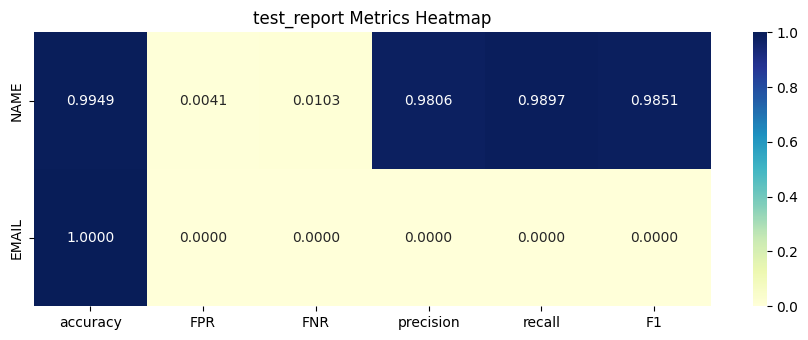

test_report token accuracy: 0.9948
Saved report: /kaggle/working/reports/test_report.csv
Saved heatmap: /kaggle/working/reports/test_report_heatmap.png
Email recall bias enabled: True, threshold=0.05


,accuracy,FPR,FNR,precision,recall,F1,support_positive
NAME,0.994869,0.004062,0.010294,0.980559,0.989706,0.985111,20691
EMAIL,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0


In [ ]:
try:
    test_df = pd.read_json(f"{BASE_DIR_DATA}/data/test_data.json")
    test_df["ner_tags"] = test_df["ner_tags"].apply(normalize_tags)
    test_ds = Dataset.from_pandas(test_df[["tokens", "ner_tags"]], preserve_index=False)
    test_tok = test_ds.map(tokenize_and_align_labels, batched=True)

    test_metrics_df = evaluate_and_report(
        model,
        test_tok,
        "test_report",
        processing_tokenizer=tokenizer,
        prioritize_email_recall=True,
        email_threshold=0.05,
    )
except FileNotFoundError:
    print(f"{BASE_DIR_DATA}/data/test_data.json not found. Skipping independent test evaluation.")

README.md: 0.00B [00:00, ?B/s]

english_pii_43k.jsonl:   0%|          | 0.00/73.8M [00:00<?, ?B/s]

french_pii_62k.jsonl:   0%|          | 0.00/116M [00:00<?, ?B/s]

german_pii_52k.jsonl:   0%|          | 0.00/97.8M [00:00<?, ?B/s]

italian_pii_50k.jsonl:   0%|          | 0.00/93.1M [00:00<?, ?B/s]

...

Counter({'O': 2021151,
         'B-PER': 30071,
         'I-PER': 45063,
         'B-EMAIL': 4067,
         'I-EMAIL': 36812})

Map:   0%|          | 0/43501 [00:00<?, ? examples/s]

AI4Privacy rows for evaluation: 43501
Using model from: /kaggle/working/roberta_pii/checkpoint-2982


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


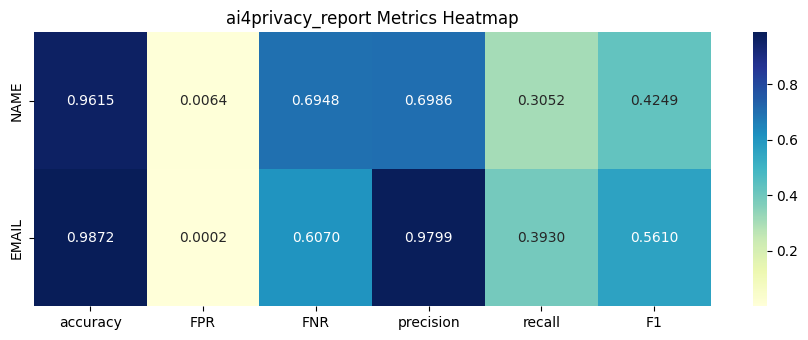

ai4privacy_report token accuracy: 0.9504
Saved report: /kaggle/working/reports/ai4privacy_report.csv
Saved heatmap: /kaggle/working/reports/ai4privacy_report_heatmap.png
Email recall bias enabled: True, threshold=0.2


,accuracy,FPR,FNR,precision,recall,F1,support_positive
NAME,0.961534,0.006427,0.694762,0.698641,0.305238,0.424856,128539
EMAIL,0.987205,0.000172,0.607001,0.979862,0.392999,0.560996,57448


In [16]:
import ast

dataset = load_dataset("ai4privacy/pii-masking-200k")


def map_ai4privacy_label(label: str) -> str:
    label_upper = str(label).upper()
    if label_upper == "O":
        return "O"

    prefix = "B-" if label_upper.startswith("B-") else "I-" if label_upper.startswith("I-") else None
    base = label_upper[2:] if prefix else label_upper

    if "EMAIL" in base:
        return (prefix or "B-") + "EMAIL"

    person_keys = ["NAME", "FIRSTNAME", "LASTNAME", "FULLNAME", "MIDDLENAME", "SURNAME", "PERSON"]
    if any(k in base for k in person_keys):
        return (prefix or "B-") + "PER"

    return "O"


def parse_list_field(value):
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            return parsed if isinstance(parsed, list) else []
        except Exception:
            return []
    return []


def convert_ai4privacy_example(example):
    tokens = parse_list_field(example.get("mbert_text_tokens", []))
    bio_labels = parse_list_field(example.get("mbert_bio_labels", []))

    if tokens and bio_labels and len(tokens) == len(bio_labels):
        mapped_tags = [map_ai4privacy_label(lbl) for lbl in bio_labels]
        return {
            "tokens": [str(t) for t in tokens],
            "ner_tags": mapped_tags,
            "lang": "en",
            "sequence": " ".join(str(t) for t in tokens),
            "keep": True,
        }

    if "tokens" in example and ("ner_tags" in example or "labels" in example):
        fallback_tokens = parse_list_field(example.get("tokens", []))
        fallback_tags = parse_list_field(example.get("ner_tags", example.get("labels", [])))
        if fallback_tokens and fallback_tags and len(fallback_tokens) == len(fallback_tags):
            mapped_tags = [map_ai4privacy_label(lbl) for lbl in fallback_tags]
            return {
                "tokens": [str(t) for t in fallback_tokens],
                "ner_tags": mapped_tags,
                "lang": "en",
                "sequence": " ".join(str(t) for t in fallback_tokens),
                "keep": True,
            }

    return {
        "tokens": [],
        "ner_tags": [],
        "lang": "en",
        "sequence": "",
        "keep": False,
    }


def count_email_tag_rows(df_local: pd.DataFrame) -> int:
    return int(df_local["ner_tags"].apply(lambda tags: any(t in ("B-EMAIL", "I-EMAIL") for t in tags)).sum())


split_name = "test" if "test" in dataset else "train"
ai4_ds_raw = dataset[split_name]

if "language" in ai4_ds_raw.column_names:
    ai4_ds_raw = ai4_ds_raw.filter(lambda x: x["language"] == "en")

ai4_converted = ai4_ds_raw.map(convert_ai4privacy_example)
ai4_df = ai4_converted.to_pandas()
ai4_df = ai4_df[ai4_df["keep"]].copy()
ai4_df = ai4_df[["tokens", "ner_tags", "lang", "sequence"]]
ai4_df = ai4_df[ai4_df["tokens"].apply(len) > 0].reset_index(drop=True)

print("AI4Privacy converted rows:", len(ai4_df))
print("AI4Privacy rows with regex-detected email string:", count_email_rows(ai4_df))
print("AI4Privacy rows with EMAIL labels:", count_email_tag_rows(ai4_df))
print()
print("AI4Privacy token-label frequency distribution:")
display(reduce(lambda frq, x: frq + Counter(x), ai4_df["ner_tags"], Counter()))

if len(ai4_df) == 0:
    raise ValueError("No usable token-level rows were converted from AI4Privacy. Check column names/format in this dataset version.")

ai4_eval_ds = Dataset.from_pandas(ai4_df[["tokens", "ner_tags"]], preserve_index=False)
ai4_eval_tok = ai4_eval_ds.map(tokenize_and_align_labels, batched=True)
print("AI4Privacy rows for evaluation:", len(ai4_eval_tok))

output_dir = Path(f"{BASE_DIR_OUTPUT}/roberta_pii")
checkpoint_dirs = sorted(output_dir.glob("checkpoint-*"), key=lambda p: int(p.name.split("-")[-1]))
model_path = checkpoint_dirs[-1] if checkpoint_dirs else output_dir
print("Using model from:", model_path)

loaded_tokenizer = AutoTokenizer.from_pretrained(str(model_path))
loaded_model = AutoModelForTokenClassification.from_pretrained(str(model_path))

ai4_metrics_df = evaluate_and_report(
    loaded_model,
    ai4_eval_tok,
    "ai4privacy_report",
    processing_tokenizer=loaded_tokenizer,
    prioritize_email_recall=True,
    email_threshold=0.20,
)